# Setup

Mount Drive in Colab, install dependencies, load one RGB-D frame.

Frame priority on disk: Isaac exports → Gazebo exports → `data/synthetic_exports/` (bundled demo).

## Project path

In [1]:
import os
import runpy

_cwd = os.getcwd()
_utils = os.path.join(_cwd, "colab_utils.py")
if not os.path.isfile(_utils):
    _utils = os.path.join(_cwd, "notebooks", "colab_utils.py")
runpy.run_path(_utils)

from notebooks.colab_utils import display_path, enable_inline_matplotlib, setup_notebook

enable_inline_matplotlib()
PROJECT_ROOT = setup_notebook()
assert os.path.isdir(PROJECT_ROOT), "Project not found at %s" % display_path(PROJECT_ROOT, project_root=PROJECT_ROOT)
print("Project root: %s" % display_path(PROJECT_ROOT, project_root=PROJECT_ROOT))

Project root: object-pose-estimation


## Dependencies

In [2]:
from notebooks.colab_utils import install_requirements

install_requirements(PROJECT_ROOT)
print("Dependencies OK")

Dependencies OK


## Environment

**Isaac Sim** is the primary sim target — it runs on a **local NVIDIA GPU**, not in Colab. This notebook checks GPU/Isaac availability for reference; exported frames on Drive are what the pipeline actually loads.

In [3]:
import subprocess

try:
    gpu_info = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        text=True,
    ).strip()
    print(f"GPU: {gpu_info}")
except Exception:
    print("No NVIDIA GPU — CPU is fine for this pipeline")

No NVIDIA GPU — CPU is fine for this pipeline


In [4]:
from notebooks.colab_utils import try_gazebo_cli, try_isaac_import

isaac_ok, isaac_msg = try_isaac_import()
gazebo_ok, gazebo_msg = try_gazebo_cli()

print(f"Isaac check: {isaac_msg}")
print(f"Gazebo check: {gazebo_msg}")
print("Isaac export runs on a local GPU workstation — notebooks load exported frames from Drive or repo.")

Isaac check: Isaac Sim not available in this runtime
Gazebo check: Gazebo not available in this runtime
Isaac export runs on a local GPU workstation — notebooks load exported frames from Drive or repo.


## First frame

Sanity check: one RGB-D pair plus ground-truth pose. Confirms the loader path works before the main pipeline.

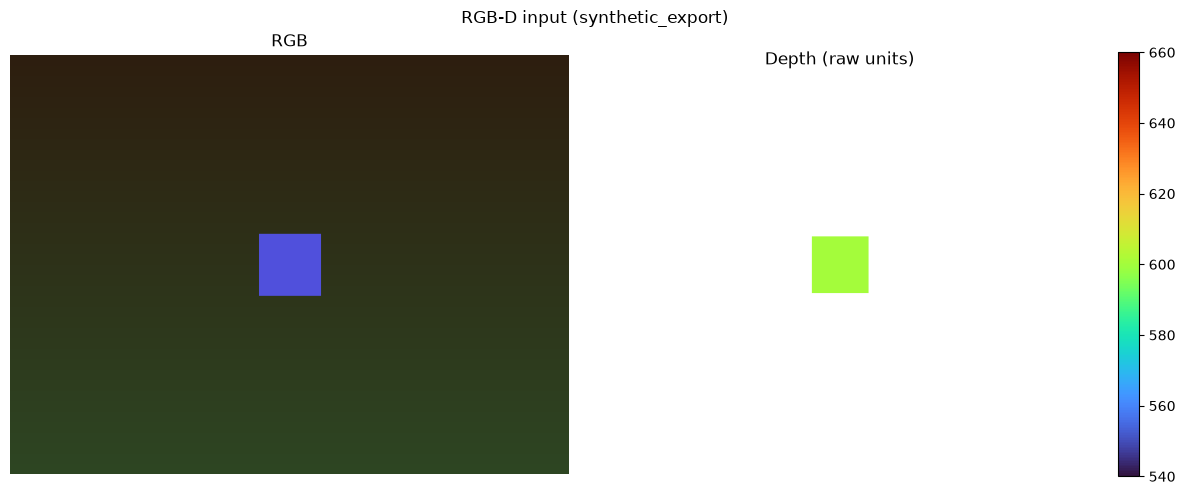

Frame source: synthetic_export
Ground truth pose (m): <data.geometry.Pose3D object at 0x113b36ed0>


In [5]:
from data.frame import load_frame
from evals.metrics import show_rgb_depth

frame = load_frame(PROJECT_ROOT)
show_rgb_depth(frame.rgb, frame.depth, title=f"RGB-D input ({frame.source})")
print(f"Frame source: {frame.source}")
print("Ground truth pose (m):", frame.gt_pose)

## Frame sources on Drive

Which export folders exist and which one `load_frame` will pick.

In [6]:
from data.frame import describe_frame_sources

for line in describe_frame_sources(PROJECT_ROOT):
    print(line)

isaac_runtime: not available (Isaac Sim not installed)
gazebo_runtime: not available (Gazebo Sim (gz) CLI not on PATH)
isaac_exports: empty (export via notebooks/data.ipynb when isaac runtime is available)
gazebo_exports: empty (export via notebooks/data.ipynb when gazebo runtime is available)
synthetic_exports: 20 bundled demo frames (object-pose-estimation/data/synthetic_exports)


## Next

Run in order: `pipeline.ipynb` → `evals.ipynb` → `ros2.ipynb`. Local C++ monitor: `./ros2/run_demo.sh` (Docker).